# Fragrantica Data Pipeline
- **Project:** Fragheadsunited AI Fragrance Recommendation Engine  
- **Dataset:** perfumes_table.csv 
- **Kolommen:** rating, notes, designer, reviews, description, url, title


## 0. Installatie & Imports

In [7]:
# Installeer benodigde packages (eenmalig, verwijder # om te installeren)
# !pip install pandas numpy sentence-transformers scikit-learn matplotlib seaborn

In [8]:
import pandas as pd
import numpy as np
import ast
import re
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from collections import Counter
warnings.filterwarnings('ignore')

pd.set_option('display.max_colwidth', 120)

## 1. Data Inladen

In [9]:
path = 'fragrantica_data/perfumes_table.csv'

df = pd.read_csv(path)

print(f'Dataset geladen: {df.shape[0]:,} rijen, {df.shape[1]} kolommen')
print(f'Kolommen: {df.columns.tolist()}')

Dataset geladen: 84,144 rijen, 7 kolommen
Kolommen: ['rating', 'notes', 'designer', 'reviews', 'description', 'url', 'title']


In [10]:
# Eerste paar rijen bekijken
df.head(5)

,rating,notes,designer,reviews,description,url,title
0,5.00,"['Vanila', 'Madagascar Vanilla', 'Vanilla Absolute']",fiorucci perfumes and colognes,[],Vanilla Scent by Fiorucci is a Amber Vanilla fragrance for women and men. Vanilla Scent was launched in 1961. Top no...,https://www.fragrantica.com/perfume/Fiorucci/Vanilla-Scent-34262.html,Vanilla Scent Fiorucci for women and men
1,4.22,"['Mint', 'Lavender', 'Nutmeg', 'elemi', 'Cypress', 'Sandalwood', 'Saffron', 'Cypriol Oil or Nagarmotha', 'Amber', 'P...",maiora parfum perfumes and colognes,[],Shady by Maiora Parfum is a fragrance for women and men. Shady was launched in 2019. The nose behind this fragrance ...,https://www.fragrantica.com/perfume/Maiora-Parfum/Shady-75400.html,Shady Maiora Parfum for women and men
2,3.81,"['Neroli', 'Vetiver', 'Basil', 'Fig']",guerlain perfumes and colognes,"[""the opening is too sharp that it reminds me of a laundry detergent, but as it settles down, the shaprness goes awa...",Nerolia Vetiver by Guerlain is a Woody Floral Musk fragrance for women and men. This is a new fragrance. Nerolia Vet...,https://www.fragrantica.com/perfume/Guerlain/Nerolia-Vetiver-71757.html,Nerolia Vetiver Guerlain for women and men
3,4.00,"['Orange Blossom', 'Star Anise', 'Pear', 'Rose', 'Mandarin Orange', 'Ylang-Ylang', 'Iris', 'Orchid', 'Plum', 'Ginger...",jean paul gaultier perfumes and colognes,['I must ask. What part of the country did this one show up in? I have not seen it in department stores in San Anton...,Classique Love Actually by Jean Paul Gaultier is a Amber Floral fragrance for women. Classique Love Actually was lau...,https://www.fragrantica.com/perfume/Jean-Paul-Gaultier/Classique-Love-Actually-11356.html,Classique Love Actually Jean Paul Gaultier for women
4,4.22,"['Petitgrain', 'Orange', 'Bergamot', 'Lemon Verbena', 'Lime', 'Grapefruit', 'Lavender', 'African Orange Flower', 'Ja...",santa maria novella perfumes and colognes,"['Beautiful and uplifting. Initially fresh and exuberant, after an hour you are left with ethereal soft green notes....",Zagara (Orange Blossom) by Santa Maria Novella is a Chypre Floral fragrance for women. Zagara (Orange Blossom) was l...,https://www.fragrantica.com/perfume/Santa-Maria-Novella/Zagara-Orange-Blossom-11470.html,Zagara (Orange Blossom) Santa Maria Novella for women


In [11]:
# Datatypes en missing values
print('Datatypes:')
print(df.dtypes)
print()
print('Missing values per kolom:')
print(df.isnull().sum())

Datatypes:
rating         float64
notes              str
designer           str
reviews            str
description        str
url                str
title              str
dtype: object

Missing values per kolom:
rating         81670
notes              0
designer           0
reviews            0
description        8
url                0
title              8
dtype: int64


## 2. Data Verkenning (EDA)

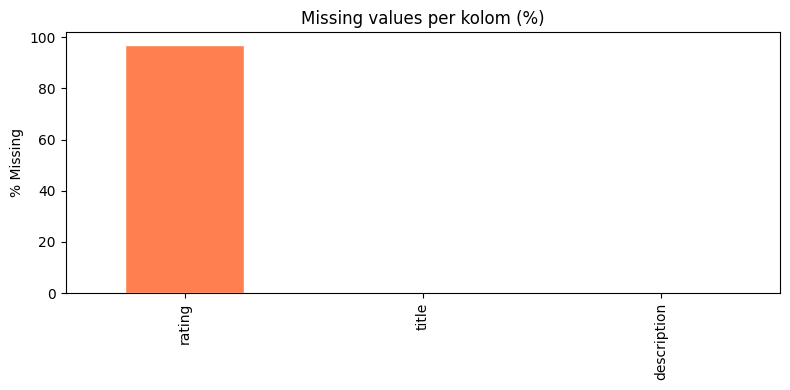

In [12]:
# Missing values visualisatie
miss_pct = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
miss_pct = miss_pct[miss_pct > 0]

if len(miss_pct) > 0:
    plt.figure(figsize=(8, 4))
    miss_pct.plot(kind='bar', color='coral', edgecolor='white')
    plt.title('Missing values per kolom (%)')
    plt.ylabel('% Missing')
    plt.tight_layout()
    plt.show()
else:
    print('Geen missing values gevonden.')

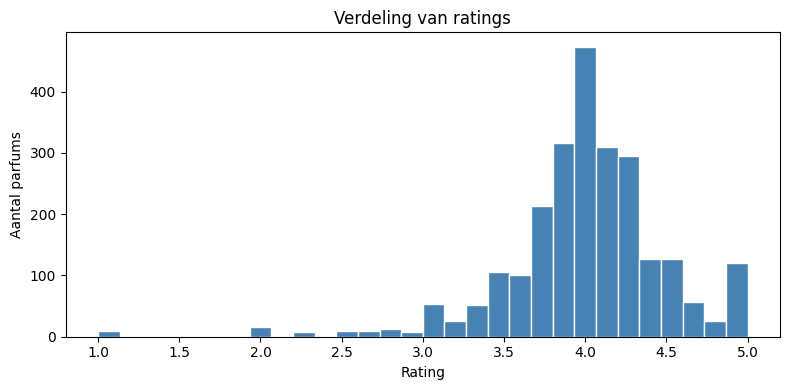

count    2474.000000
mean        3.990061
std         0.512335
min         1.000000
25%         3.790000
50%         4.000000
75%         4.250000
max         5.000000
Name: rating, dtype: float64


In [13]:
# Rating verdeling
df['rating'] = pd.to_numeric(df['rating'], errors='coerce')

plt.figure(figsize=(8, 4))
df['rating'].dropna().plot(kind='hist', bins=30, color='steelblue', edgecolor='white')
plt.title('Verdeling van ratings')
plt.xlabel('Rating')
plt.ylabel('Aantal parfums')
plt.tight_layout()
plt.show()

print(df['rating'].describe())

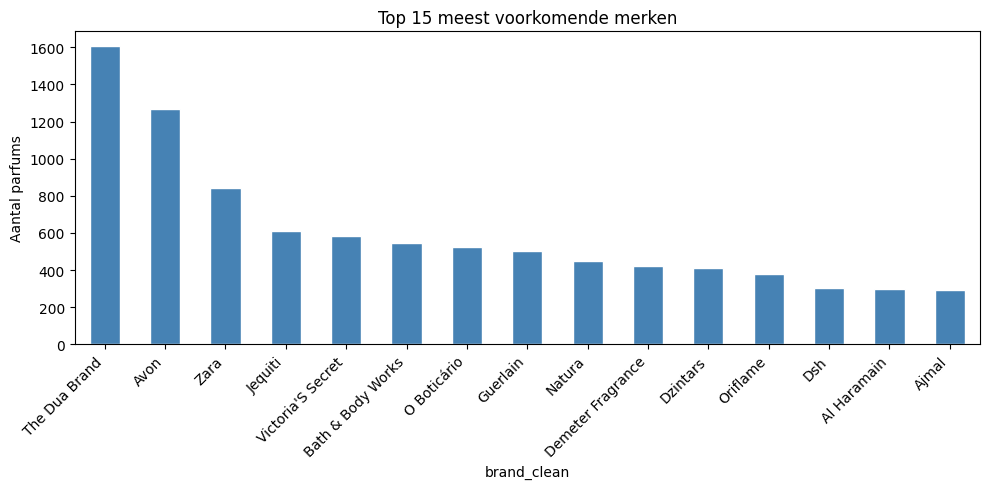

In [14]:
# Top 15 designers (merken)
# 'designer' kolom bevat bijv. 'guerlain perfumes and colognes'
# We extraheren het gedeelte voor 'perfumes' of 'cologne'
df['brand_clean'] = df['designer'].str.split(' perfumes').str[0].str.title()

top_brands = df['brand_clean'].value_counts().head(15)

plt.figure(figsize=(10, 5))
top_brands.plot(kind='bar', color='steelblue', edgecolor='white')
plt.title('Top 15 meest voorkomende merken')
plt.ylabel('Aantal parfums')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

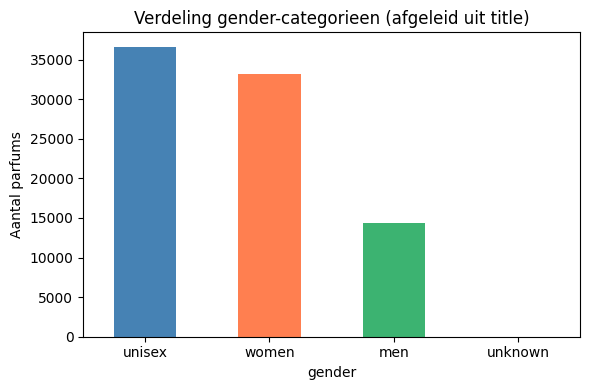

gender
unisex     36616
women      33131
men        14389
unknown        8
Name: count, dtype: int64


In [15]:
# Gender afleiden uit title
def extract_gender(title):
    if not isinstance(title, str):
        return 'unknown'
    t = title.lower()
    if 'for women and men' in t or 'unisex' in t:
        return 'unisex'
    elif 'for women' in t:
        return 'women'
    elif 'for men' in t:
        return 'men'
    return 'unknown'

df['gender'] = df['title'].apply(extract_gender)

gender_counts = df['gender'].value_counts()
plt.figure(figsize=(6, 4))
gender_counts.plot(kind='bar', color=['steelblue', 'coral', 'mediumseagreen', 'gray'])
plt.title('Verdeling gender-categorieen (afgeleid uit title)')
plt.ylabel('Aantal parfums')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()
print(gender_counts)

## 3. Notes & Reviews Parsen

Beide kolommen zijn opgeslagen als string-representatie van een Python lijst:  
"['Vanilla', 'Lavender', 'Sandalwood']" wordt omgezet naar een echte lijst.

In [16]:
def parse_list_column(val):
    """Zet string-lijst om naar echte Python list."""
    if pd.isna(val) or str(val).strip() in ('[]', ''):
        return []
    try:
        result = ast.literal_eval(val)
        return result if isinstance(result, list) else [str(result)]
    except:
        return [str(val)]


def clean_text(text):
    """Basis tekstopschoning."""
    if not isinstance(text, str):
        return ''
    text = text.strip()
    text = re.sub(r'\s+', ' ', text)
    text = text.replace("\\'s", "'s").replace('\\"', '"')
    return text


# Parsen
df['notes_list']   = df['notes'].apply(parse_list_column)
df['reviews_list'] = df['reviews'].apply(parse_list_column)

# Tekstvelden
df['notes_text']   = df['notes_list'].apply(lambda lst: ', '.join(lst))
df['reviews_text'] = df['reviews_list'].apply(
    lambda lst: ' '.join([clean_text(r) for r in lst if isinstance(r, str) and len(r) > 20])
)
df['review_count'] = df['reviews_list'].apply(len)

print(f'Parfums met reviews:    {(df["review_count"] > 0).sum():,}')
print(f'Parfums zonder reviews: {(df["review_count"] == 0).sum():,}')
print(f'Gemiddeld per parfum:   {df["review_count"].mean():.1f}')
print()
print('Voorbeeld notes_text:')
print(df['notes_text'].iloc[2])
print()
print('Voorbeeld reviews_text (eerste 300 tekens):')
print(df[df['review_count'] > 0]['reviews_text'].iloc[0][:300])

Parfums met reviews:    54,033
Parfums zonder reviews: 30,111
Gemiddeld per parfum:   15.9

Voorbeeld notes_text:
Neroli, Vetiver, Basil, Fig

Voorbeeld reviews_text (eerste 300 tekens):
the opening is too sharp that it reminds me of a laundry detergent, but as it settles down, the shaprness goes away and i get to sense the fresh, orangey, soft, floral qualities of the neroli, which is the main event of this scent. It also has a green, herbaceous tone in it, which is probably courte


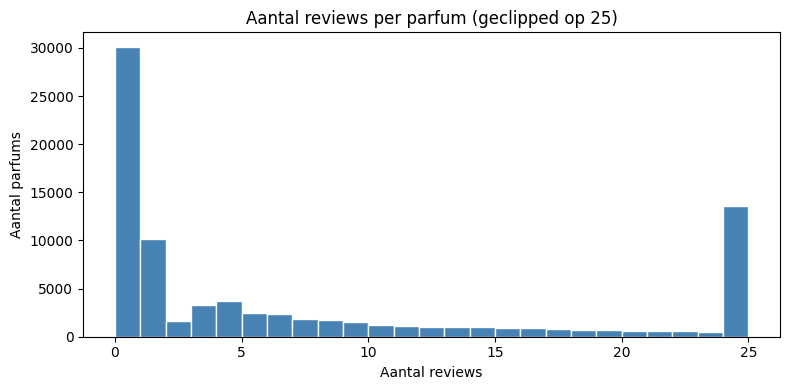

In [17]:
# Review count verdeling
plt.figure(figsize=(8, 4))
df['review_count'].clip(upper=25).plot(kind='hist', bins=25, color='steelblue', edgecolor='white')
plt.title('Aantal reviews per parfum (geclipped op 25)')
plt.xlabel('Aantal reviews')
plt.ylabel('Aantal parfums')
plt.tight_layout()
plt.show()

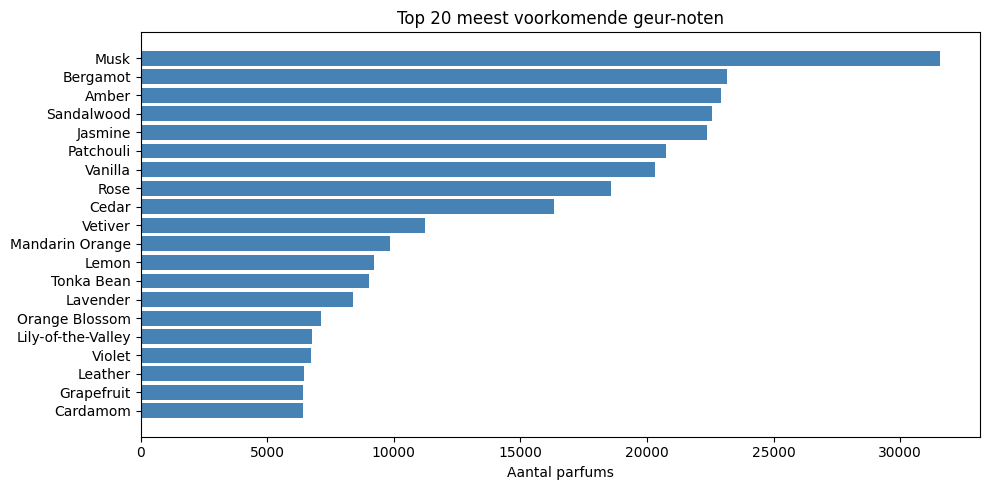

In [18]:
# Meest voorkomende geur-noten
all_notes = [note for notes in df['notes_list'] for note in notes]
top_notes = Counter(all_notes).most_common(20)
notes_df = pd.DataFrame(top_notes, columns=['Note', 'Count'])

plt.figure(figsize=(10, 5))
plt.barh(notes_df['Note'][::-1], notes_df['Count'][::-1], color='steelblue')
plt.title('Top 20 meest voorkomende geur-noten')
plt.xlabel('Aantal parfums')
plt.tight_layout()
plt.show()

## 4. Beschrijving & Text Analyse

In [ ]:
# Beschrijvingstekst analyse
df['description_length'] = df['description'].fillna('').str.len()
df['description_word_count'] = df['description'].fillna('').str.split().str.len()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df['description_length'], bins=30, color='mediumseagreen', edgecolor='white')
axes[0].set_title('Verdeling beschrijving lengte (characters)')
axes[0].set_xlabel('Aantal karakters')
axes[0].set_ylabel('Aantal parfums')

axes[1].hist(df['description_word_count'], bins=30, color='mediumseagreen', edgecolor='white')
axes[1].set_title('Verdeling beschrijving lengte (woorden)')
axes[1].set_xlabel('Aantal woorden')
axes[1].set_ylabel('Aantal parfums')

plt.tight_layout()
plt.show()

print(f'Beschrijvingen met tekst: {(df["description_length"] > 0).sum():,}')
print(f'Beschrijvingen zonder tekst: {(df["description_length"] == 0).sum():,}')
print(f'Gemiddelde lengte: {df["description_length"].mean():.0f} karakters')
print(f'Gemiddelde woordenaantal: {df["description_word_count"].mean():.0f} woorden')


## 5. URL & Brand Analyse

In [ ]:
# URL analyse
df['has_url'] = df['url'].notna() & (df['url'] != '')
print(f'Parfums met URL: {df["has_url"].sum():,} ({df["has_url"].mean()*100:.1f}%)')

# Rating statistieken per brand
brand_stats = df.groupby('brand_clean').agg({
    'rating': ['count', 'mean', 'std', 'min', 'max'],
    'review_count': 'mean',
    'description_length': 'mean'
}).round(2)

brand_stats.columns = ['Count', 'Avg Rating', 'Std Dev', 'Min', 'Max', 'Avg Reviews', 'Avg Desc Length']
brand_stats = brand_stats.sort_values('Count', ascending=False).head(15)

print('\nTop 15 brands - statistieken:')
print(brand_stats)


In [ ]:
# Rating per gender
gender_stats = df.groupby('gender').agg({
    'rating': ['count', 'mean', 'std'],
    'review_count': 'mean',
    'description_length': 'mean'
}).round(2)

gender_stats.columns = ['Count', 'Avg Rating', 'Std Dev', 'Avg Reviews', 'Avg Desc Length']
print('\nRating statistieken per geslacht:')
print(gender_stats)

# Visualisatie
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Box plot van ratings per gender
df.boxplot(column='rating', by='gender', ax=axes[0])
axes[0].set_title('Rating verdeling per geslacht')
axes[0].set_xlabel('Geslacht')
axes[0].set_ylabel('Rating')
plt.sca(axes[0])
plt.xticks(rotation=0)

# Reviews per gender
gender_reviews = df.groupby('gender')['review_count'].mean().sort_values(ascending=False)
axes[1].bar(gender_reviews.index, gender_reviews.values, color='coral', edgecolor='white')
axes[1].set_title('Gemiddeld aantal reviews per geslacht')
axes[1].set_xlabel('Geslacht')
axes[1].set_ylabel('Avg reviews')
plt.sca(axes[1])
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


## 6. Numerieke Correlaties

In [ ]:
# Correlatie matrix
numeric_cols = ['rating', 'review_count', 'description_length', 'description_word_count']
corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, 
            square=True, linewidths=1, cbar_kws={"shrink": 0.8}, fmt='.2f')
plt.title('Correlatie matrix - numerieke features')
plt.tight_layout()
plt.show()

print('Correlatie samenvatting:')
print(corr_matrix)


## 7. Data Kwaliteit & Samenvattting

In [ ]:
# Data kwaliteit checks
print('=== DATA KWALITEIT CHECKS ===')
print()

# Duplicaten
duplicates = df.duplicated(subset=['title']).sum()
print(f'Dubbele titels: {duplicates}')

# Outliers in ratings
q1_rating = df['rating'].quantile(0.25)
q3_rating = df['rating'].quantile(0.75)
iqr = q3_rating - q1_rating
outliers_rating = df[(df['rating'] < q1_rating - 1.5*iqr) | (df['rating'] > q3_rating + 1.5*iqr)].shape[0]
print(f'Outliers in ratings (IQR methode): {outliers_rating}')

# Incomplete records
incomplete = df[df[['title', 'rating', 'designer', 'description']].isnull().any(axis=1)].shape[0]
print(f'Onvolledige records (geen title/rating/designer/description): {incomplete}')

# Consistency checks
print(f'\nConsistency checks:')
print(f'Unieke brands: {df["brand_clean"].nunique()}')
print(f'Unieke geslachten: {df["gender"].nunique()}')
print(f'Rating range: {df["rating"].min():.1f} - {df["rating"].max():.1f}')
print(f'Max aantal reviews per parfum: {df["review_count"].max():.0f}')


In [ ]:
# Finale samenvattting
print('\n=== DATASAMENVATTING ===')
print()
print(f'Totale parfums: {df.shape[0]:,}')
print(f'Features: {df.shape[1]}')
print()
print('Data beschikbaarheid:')
for col in ['title', 'rating', 'designer', 'description', 'url', 'notes', 'reviews']:
    pct = (df[col].notna().sum() / len(df) * 100)
    print(f'  {col:12s}: {pct:6.1f}%')
print()
print('Key inzichten:')
print(f'  - Gemiddelde rating: {df["rating"].mean():.2f} / 10')
print(f'  - Populairste brand: {df["brand_clean"].value_counts().index[0]} ({df["brand_clean"].value_counts().iloc[0]} parfums)')
print(f'  - Gender verdeling: {dict(df["gender"].value_counts())}')
print(f'  - Parfums met reviews: {(df["review_count"] > 0).sum():,} ({(df["review_count"] > 0).mean()*100:.1f}%)')
print(f'  - Gemiddeld aantal noten per parfum: {df["notes_list"].str.len().mean():.1f}')
